# Chapter 10 tutorial — Part 1: sampling by attributes and sampling plans

This notebook turns the first half of Chapter 10 into executable examples.

## Mental model

A sample is a **noisy lens** pointed at a lot.

- The **lot** is the full collection of units.
- The **sample** is the part you inspect.
- In **sampling by attributes**, each inspected unit is reduced to a binary label: defective or non-defective.
- The sample's **fraction defective** estimates the lot's fraction defective.

The key design question is not “what fraction of the lot did we sample?” but “how noisy is the decision we are making?”

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, hypergeom, norm, chi2
from scipy.optimize import brentq

pd.set_option("display.precision", 4)

## 1. Lot, sample, defective count, fraction defective

If 5 pills out of a sample of 200 are defective, the sample fraction defective is

$$
\hat p = \frac{5}{200} = 0.025.
$$

This is not automatically the lot fraction defective. It is a noisy observation of the lot.

In [2]:
def fraction_defective(defective, sample_size):
    return defective / sample_size

fraction_defective(5, 200)

0.025

## 2. Principle I: lot size has little effect once the lot is much larger than the sample

The exact distribution without replacement is hypergeometric:

$$
P(X=x) = \frac{\binom{D}{x}\binom{N-D}{n-x}}{\binom{N}{n}},
$$

where:

- $N$ = lot size,
- $D$ = number defective in the lot,
- $n$ = sample size,
- $X$ = defectives in the sample.

When $N$ is much larger than $n$, this is very close to the binomial model:

$$
X \sim \mathrm{Binomial}(n, p), \quad p = D/N.
$$

Mental model: after the lot is “large enough,” the sample mostly sees the **defective rate**, not the total lot size.

In [3]:
def defect_distribution_table(lot_size, defect_rate, sample_size, max_explicit=4):
    D = round(lot_size * defect_rate)
    rows = []
    for x in range(max_explicit + 1):
        rows.append((str(x), 100 * hypergeom.pmf(x, lot_size, D, sample_size)))
    tail = 100 * (1 - hypergeom.cdf(max_explicit, lot_size, D, sample_size))
    rows.append((f"{max_explicit+1} or more", tail))
    return pd.DataFrame(rows, columns=["defectives in sample", f"lot={lot_size}, sample={sample_size}"])

t1_large = defect_distribution_table(10_000, 0.10, 10)
t1_small = defect_distribution_table(100, 0.10, 10)
comparison = t1_large.merge(t1_small, on="defectives in sample")
comparison

,defectives in sample,"lot=10000, sample=10","lot=100, sample=10"
0,0,34.8504,33.0476
1,1,38.7614,40.7995
2,2,19.3786,20.1510
3,3,5.7348,5.1794
4,4,1.1125,0.7553
5,5 or more,0.1623,0.0672


The two columns are close even though the sample is $0.1\%$ of one lot and $10\%$ of the other. That is the practical meaning of Principle I.

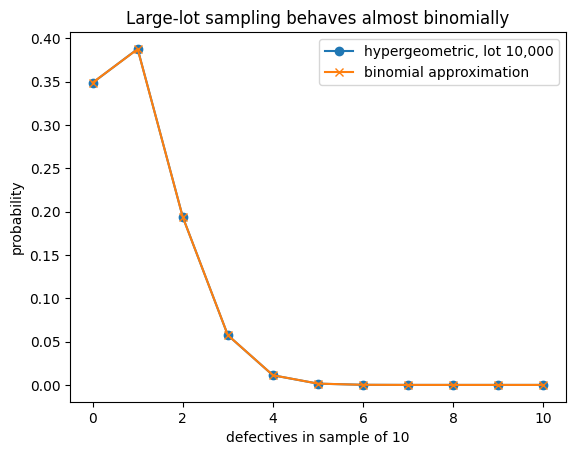

In [4]:
# Compare hypergeometric to binomial directly for the larger lot.
ks = np.arange(0, 11)
plt.figure()
plt.plot(ks, hypergeom.pmf(ks, 10_000, 1_000, 10), marker="o", label="hypergeometric, lot 10,000")
plt.plot(ks, binom.pmf(ks, 10, 0.10), marker="x", label="binomial approximation")
plt.xlabel("defectives in sample of 10")
plt.ylabel("probability")
plt.title("Large-lot sampling behaves almost binomially")
plt.legend()
plt.show()

## 3. Principle II: larger samples contain more information

A larger sample has a smaller standard error. For an attribute sample,

$$
\mathrm{SE}(\hat p) \approx \sqrt{\frac{p(1-p)}{n}}.
$$

The $1/\sqrt n$ law appears everywhere in sampling: to reduce sampling noise by a factor of 2, you need about 4 times the sample size.

In [5]:
def prob_sample_percent_between(lot_size, defect_rate, sample_size, lo=0.05, hi=0.15):
    D = round(lot_size * defect_rate)
    k_min = math.ceil(lo * sample_size)
    k_max = math.floor(hi * sample_size)
    ks = np.arange(k_min, k_max + 1)
    return hypergeom.pmf(ks, lot_size, D, sample_size).sum()

rows = []
for n in [10, 20, 100]:
    rows.append({
        "sample size": n,
        "count range for 5% to 15%": f"{math.ceil(.05*n)} to {math.floor(.15*n)}",
        "probability": prob_sample_percent_between(100_000, 0.10, n),
        "standard error of p-hat": math.sqrt(0.1 * 0.9 / n)
    })
pd.DataFrame(rows)

,sample size,count range for 5% to 15%,probability,standard error of p-hat
0,10,1 to 1,0.3874,0.0949
1,20,1 to 3,0.7455,0.0671
2,100,5 to 15,0.9365,0.0300


<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\hadi\AppData\Local\Temp\ipykernel_32156\56194688.py:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.title("Sampling noise falls like $1/\sqrt{n}$")


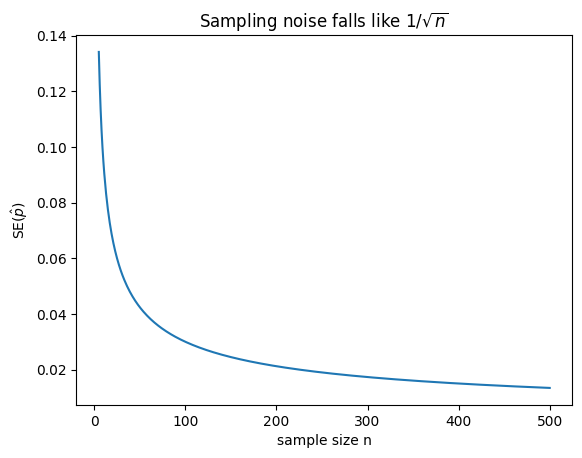

In [6]:
ns = np.arange(5, 501)
se = np.sqrt(0.1 * 0.9 / ns)
plt.figure()
plt.plot(ns, se)
plt.xlabel("sample size n")
plt.ylabel(r"SE($\hat p$)")
plt.title("Sampling noise falls like $1/\sqrt{n}$")
plt.show()

## 4. Principle III: proportional samples can be misleading

A common mistake is to sample a fixed percentage of each lot. That makes smaller lots receive smaller samples, and therefore noisier decisions.

The following reproduces the idea of the chapter's “inadequacy of samples proportional to lot” example.

In [7]:
def proportional_sample_table(lot_size, sample_size, defect_rate=0.10):
    D = round(lot_size * defect_rate)
    p0 = hypergeom.pmf(0, lot_size, D, sample_size)
    # "between 0 and 20%" is interpreted as strictly greater than 0 and strictly less than 20%.
    upper_exclusive = math.ceil(0.20 * sample_size)
    p_mid = hypergeom.pmf(np.arange(1, upper_exclusive), lot_size, D, sample_size).sum()
    p_high = 1 - p0 - p_mid
    return [100 * p0, 100 * p_mid, 100 * p_high]

table = pd.DataFrame({
    "sample percent defective": ["0", "between 0 and 20", "20 or more"],
    "lot 200, sample 20": proportional_sample_table(200, 20),
    "lot 100, sample 10": proportional_sample_table(100, 10),
})
table

,sample percent defective,"lot 200, sample 20","lot 100, sample 10"
0,0,10.8542,33.0476
1,between 0 and 20,76.9216,40.7995
2,20 or more,12.2242,26.1528


Both samples are $10\%$ of their lots, but the sample of 10 is much noisier than the sample of 20.

Mental model: **sample size is the volume knob for information**. The sample-to-lot fraction is usually not the main knob.

## 5. Sampling plans

A sampling plan says:

1. inspect $n$ units,
2. count defectives $X$,
3. accept the lot if $X \le c$,
4. reject the lot if $X \ge r$.

For a single sampling plan with no gray zone,

$$
r = c + 1.
$$

For large lots with defective fraction $p$,

$$
P(\text{accept}) = P(X \le c), \quad X \sim \mathrm{Binomial}(n,p).
$$

This acceptance probability as a function of $p$ is the **operating characteristic curve**, or **OC curve**.

Mental model: the OC curve is the plan's **contract**. It tells producer and consumer how the plan behaves for lots of every possible quality.

In [8]:
def p_accept_attributes(p, n, c):
    return binom.cdf(c, n, p)

plans = pd.DataFrame([
    ("A", 5, 1, 2),
    ("B", 7, 1, 2),
    ("C", 15, 2, 3),
    ("D", 22, 2, 3),
    ("E", 45, 4, 5),
], columns=["plan", "sample size n", "acceptance number c", "rejection number r"])
plans

,plan,sample size n,acceptance number c,rejection number r
0,A,5,1,2
1,B,7,1,2
2,C,15,2,3
3,D,22,2,3
4,E,45,4,5


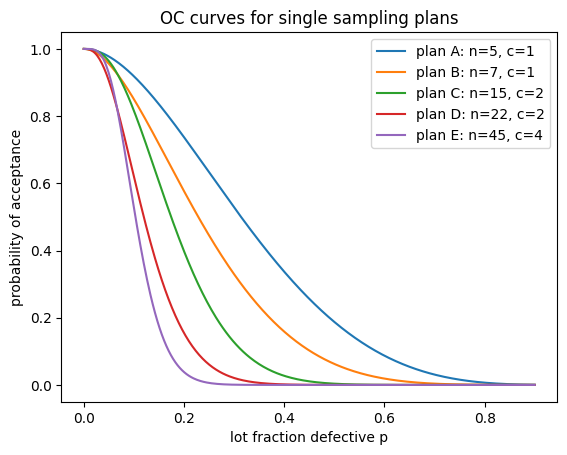

In [9]:
ps = np.linspace(0, 0.9, 400)
plt.figure()
for _, row in plans.iterrows():
    plt.plot(ps, p_accept_attributes(ps, row["sample size n"], row["acceptance number c"]), label=f"plan {row['plan']}: n={row['sample size n']}, c={row['acceptance number c']}")
plt.xlabel("lot fraction defective p")
plt.ylabel("probability of acceptance")
plt.title("OC curves for single sampling plans")
plt.legend()
plt.show()

A steeper OC curve is “better” when the goal is to clearly distinguish good lots from bad lots. Bigger samples usually make the transition sharper.

## 6. AQL, RQL, producer's risk, consumer's risk

Two important points on an OC curve are often used to summarize a plan:

- **AQL**: acceptable quality level. At this quality, the lot should usually be accepted.
- **RQL** or **LTPD**: rejectable quality level / lot tolerance percent defective. At this quality, the lot should usually be rejected.

If

$$
P(\text{accept at AQL}) = 1 - \alpha,
$$

then $\alpha$ is the **producer's risk**: the chance of rejecting a good lot.

If

$$
P(\text{accept at RQL}) = \beta,
$$

then $\beta$ is the **consumer's risk**: the chance of accepting a bad lot.

In [10]:
def p_for_acceptance_probability(target, n, c):
    f = lambda p: p_accept_attributes(p, n, c) - target
    return brentq(f, 0, 0.999999)

plan_A_n = 5
plan_A_c = 1
alpha = 0.05
beta = 0.10
AQL = p_for_acceptance_probability(1 - alpha, plan_A_n, plan_A_c)
RQL = p_for_acceptance_probability(beta, plan_A_n, plan_A_c)

pd.DataFrame([
    {"quantity": "AQL when producer's risk alpha = 0.05", "value": AQL},
    {"quantity": "RQL when consumer's risk beta = 0.10", "value": RQL},
])

,quantity,value
0,AQL when producer's risk alpha = 0.05,0.0764
1,RQL when consumer's risk beta = 0.10,0.5839


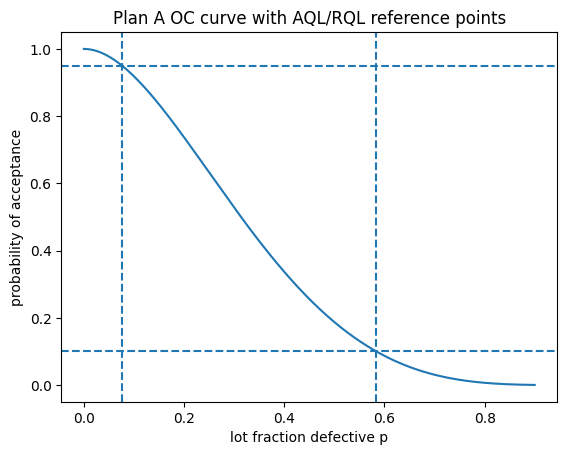

In [11]:
ps = np.linspace(0, 0.9, 400)
pa = p_accept_attributes(ps, plan_A_n, plan_A_c)
plt.figure()
plt.plot(ps, pa)
plt.axhline(1-alpha, linestyle="--")
plt.axhline(beta, linestyle="--")
plt.axvline(AQL, linestyle="--")
plt.axvline(RQL, linestyle="--")
plt.xlabel("lot fraction defective p")
plt.ylabel("probability of acceptance")
plt.title("Plan A OC curve with AQL/RQL reference points")
plt.show()

## 7. Single, double, multiple, and sequential sampling plans

A single plan ends after one sample. More complex plans introduce a gray zone:

- **Double sampling**: if the first sample is inconclusive, inspect a second sample.
- **Multiple sampling**: more than two possible sampling stages.
- **Sequential sampling**: no fixed maximum number of samples is predetermined; the decision boundary depends on the accumulated evidence.

Mental model: multi-stage plans spend extra inspection effort only when the first evidence is ambiguous.

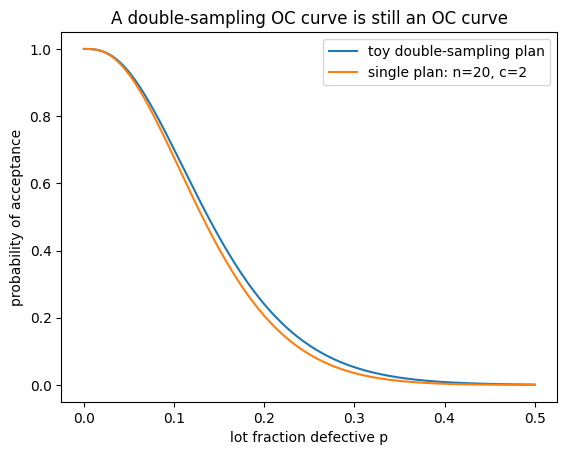

In [12]:
def toy_double_sampling(p, n1=10, c1=0, r1=3, n2=10, c_total=2):
    """Return probability of acceptance for a simple double-sampling plan.

    First sample:
      accept immediately if X1 <= c1
      reject immediately if X1 >= r1
      otherwise take second sample and accept if X1 + X2 <= c_total
    """
    prob = 0.0
    for x1 in range(n1 + 1):
        px1 = binom.pmf(x1, n1, p)
        if x1 <= c1:
            prob += px1
        elif x1 >= r1:
            prob += 0
        else:
            max_x2 = c_total - x1
            prob += px1 * binom.cdf(max_x2, n2, p)
    return prob

ps = np.linspace(0, 0.5, 300)
plt.figure()
plt.plot(ps, [toy_double_sampling(p) for p in ps], label="toy double-sampling plan")
plt.plot(ps, binom.cdf(2, 20, ps), label="single plan: n=20, c=2")
plt.xlabel("lot fraction defective p")
plt.ylabel("probability of acceptance")
plt.title("A double-sampling OC curve is still an OC curve")
plt.legend()
plt.show()

## 8. Why sampling plans should not be confused with process control

If each successive lot comes from the same stable process, with the same true fraction defective, sampling does not magically separate good lots from bad lots. It randomly labels some lots accepted and some rejected.

Sampling plans are most meaningful when lots may actually differ in quality, or when the source/process is not already known to be in statistical control.

In [ ]:
rng = np.random.default_rng(123)

# Stable process: every lot has exactly the same true defective rate.
p_true_stable = np.full(20_000, 0.10)
observed_defects = rng.binomial(20, p_true_stable)
accepted = observed_defects <= 2

stable_summary = pd.DataFrame({
    "group": ["accepted", "rejected"],
    "number of lots": [accepted.sum(), (~accepted).sum()],
    "average true defect rate": [p_true_stable[accepted].mean(), p_true_stable[~accepted].mean()]
})
stable_summary

In [ ]:
# Mixed source: lots really do differ in quality.
p_true_mixed = rng.beta(2, 18, size=20_000)  # average near 0.10, but lots vary
observed_defects = rng.binomial(20, p_true_mixed)
accepted = observed_defects <= 2

mixed_summary = pd.DataFrame({
    "group": ["accepted", "rejected"],
    "number of lots": [accepted.sum(), (~accepted).sum()],
    "average true defect rate": [p_true_mixed[accepted].mean(), p_true_mixed[~accepted].mean()]
})
mixed_summary

## 9. Design checklist

When using an attribute sampling plan, state these explicitly:

1. What is a unit?
2. What counts as defective?
3. What sample size $n$ will be inspected?
4. What acceptance number $c$ will be used?
5. What AQL, RQL, producer's risk, and consumer's risk does the plan imply?
6. Are lots coming from a stable process? If yes, use control charts for process control rather than pretending acceptance sampling is process improvement.